In [6]:
# 进行文件初始化并读取整个h5实验数据文件
import numpy as np
import h5py
import matplotlib.pyplot as plt

pid = 553
file_path = r"D:\yangyuanming\artiq_control\302adc_dds2_ttl2\experiment\results\2025-08-18\18\000000553-BaseSequence.h5"

try:
    with h5py.File(file_path, 'r') as file:
        print(f"open h5 file succeed:{file_path}")
        print("=" * 50)

        for name in file.keys():
            print(f"-{name}: {type(file[name])}")

        print("\n"+"="*50)

        def print_structure(name, obj):
            """递归打印H5文件结构"""
            if isinstance(obj, h5py.Group):
                print(f"Group: {name}")
            elif isinstance(obj, h5py.Dataset):
                print(f"Dataset: {name}, shape: {obj.shape}, type: {obj.dtype}")
            
        file.visititems(print_structure)

        print("\n"+"="*50)

        path = f'datasets/ndscan.rid_{pid}.points.channel_counts'

        if path in file:
            print(f"read dataset: {path}")
            dataset = np.array(file[path])
            # print(dataset.shape)

except FileNotFoundError:
    print(f"Error: can't find file {file_path}")
except OSError as e:
    print(f"Error: can't open file {file_path}")
except Exception as e:
    print(f"Error in operate file {e}")

open h5 file succeed:D:\yangyuanming\artiq_control\302adc_dds2_ttl2\experiment\results\2025-08-18\18\000000553-BaseSequence.h5
-archive: <class 'h5py._hl.group.Group'>
-artiq_version: <class 'h5py._hl.dataset.Dataset'>
-datasets: <class 'h5py._hl.group.Group'>
-expid: <class 'h5py._hl.dataset.Dataset'>
-rid: <class 'h5py._hl.dataset.Dataset'>
-run_time: <class 'h5py._hl.dataset.Dataset'>
-start_time: <class 'h5py._hl.dataset.Dataset'>

Group: archive
Dataset: artiq_version, shape: (), type: object
Group: datasets
Dataset: datasets/ndscan.rid_553.analysis_results, shape: (), type: object
Dataset: datasets/ndscan.rid_553.annotations, shape: (), type: object
Dataset: datasets/ndscan.rid_553.axes, shape: (), type: object
Dataset: datasets/ndscan.rid_553.channels, shape: (), type: object
Dataset: datasets/ndscan.rid_553.completed, shape: (), type: bool
Dataset: datasets/ndscan.rid_553.fragment_fqn, shape: (), type: object
Dataset: datasets/ndscan.rid_553.ndscan_schema_revision, shape: (), t

In [7]:
# 给出ndscan的处理代码
def group_from_one_axis_scan(arr, column):
    """one_axis_scan数据按参数分组，arr是测出来的dataset，column为参数所在列"""

    second_col = arr[:, column]
    
    # 获取第二列的唯一值及其索引
    unique_vals, indices = np.unique(second_col, return_inverse=True)
    
    # 按唯一值分组
    grouped = np.array([arr[indices == i] for i in range(len(unique_vals))])
    
    return grouped, unique_vals

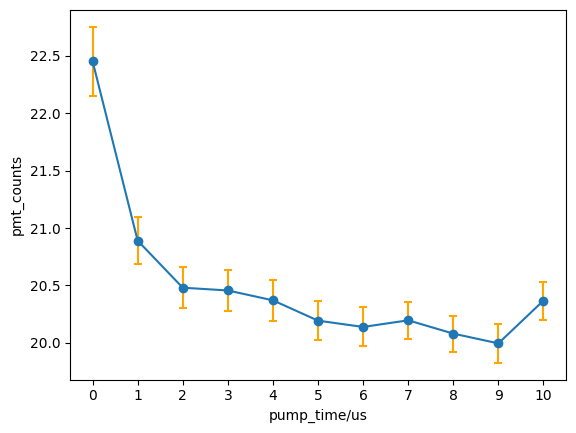

In [8]:
# 已读取数据集，进行数据处理，画出扫描pump_time后的计数率
# 计数实验总次数
N = len(dataset)
column = 1
parameter = ["cooling", "pumping", "detection"]

grouped, unique_vals = group_from_one_axis_scan(dataset, 1)
one_point_num = len(grouped[0,:]) # 单个参数点测量次数

plt.errorbar(
    unique_vals*10**6, # us
    np.mean(grouped[:,:,3],axis=1), 
    np.std(grouped[:,:,3],axis=1,ddof=1)/np.sqrt(one_point_num),
    fmt='-o',  # 圆形标记+实线
    ecolor='orange', elinewidth=1.5,
    capsize=3, capthick=1.5,
    # label=f'λ={lamb2}, N={N}, detection_time={100*detect_time}us'
)

plt.xlabel("pump_time/us")
plt.xticks(unique_vals*10**6)
plt.ylabel("pmt_counts")

file_name = f"{parameter[column]}"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

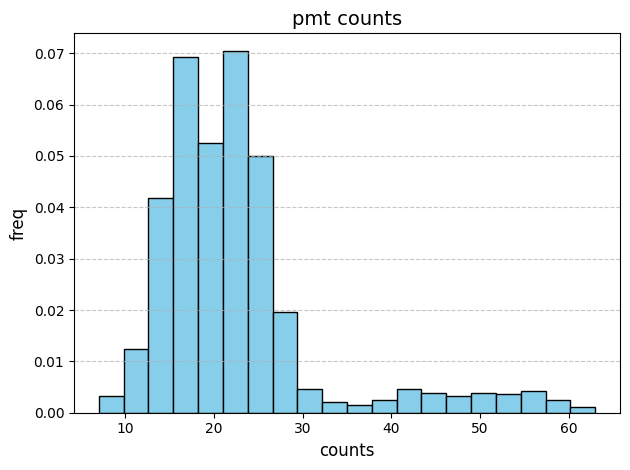

In [9]:
# 给出光子计数的分布直方图
def plot_frequency_histogram(data, bins=10, title="Frequency Distribution Histogram", 
                             xlabel="Value", ylabel="Frequency", 
                             color='skyblue', edgecolor='black',
                             density=True, grid=True):
    """
    绘制频率分布直方图，图表中使用英文字体
    
    参数:
        data: 输入数据（数组或列表）
        bins: 分箱数量，默认为10
        title: 图表标题（英文）
        xlabel: x轴标签（英文）
        ylabel: y轴标签（英文）
        color: 直方图颜色
        edgecolor: 直方图边缘颜色
        density: 是否归一化（显示频率而非计数），默认为True
        grid: 是否显示网格，默认为True
    """
    # 重置字体设置，使用默认英文字体
    plt.rcParams["font.family"] = ["sans-serif"]  # 使用默认无衬线字体
    plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号，不影响英文
    
    # 绘制直方图
    n, bins, patches = plt.hist(data, bins=bins, density=density,
                                color=color, edgecolor=edgecolor)
    
    # 添加标题和标签（均为英文）
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    # 显示网格
    if grid:
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 调整布局
    plt.tight_layout()
    
    return plt

datasetgrouped, unique_vals = group_from_one_axis_scan(dataset, 1)
pmt_counts = datasetgrouped[0,:,3]

# 绘制直方图
plt = plot_frequency_histogram(
    pmt_counts,
    bins=20,  # 分箱数量
    title="pmt counts",
    xlabel="counts",
    ylabel="freq",
    # color='lightgreen',
    # edgecolor='darkgreen'
)

# 显示图形
plt.show()


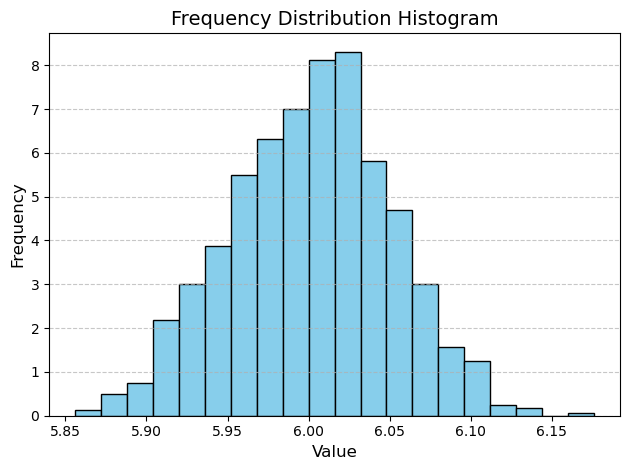

In [164]:
a = np.random.binomial(10,0.6,(1000,1000))
a_mean = np.mean(a,axis=0)
plot_frequency_histogram(a_mean,bins=20)
plt.show()